# Notebook 11 — Map AI Clusters to the Hubble Image

## Objective

In Notebook 09, K-Means clustering grouped the detected astronomical sources into
three data-driven populations. Notebook 10 used Principal Component Analysis
(PCA) to understand the feature space that produced those clusters.

In this notebook we reconnect the machine learning results with the original
Hubble image.

We will:

- Load the clustered astronomical catalog.
- Overlay each detected source on the Hubble image.
- Color-code sources according to their AI cluster assignment.
- Identify the unusual galaxies discovered by the clustering algorithm.
- Examine their physical properties and image locations.
- Determine whether these objects represent genuine astronomical outliers or artifacts of the source detection process.

By the end of this notebook we will have completed the journey from
raw Hubble pixels to interpretable AI discoveries.

In [1]:
# Cell 2 - Import Libraries ===================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ImageNormalize, PercentileInterval

plt.rcParams["figure.figsize"] = (10, 10)

In [2]:
# Cell 3 - Load the Hubble Image ===============================

image_file = Path(
    "../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits"
)

with fits.open(image_file) as hdul:
    image = hdul["SCI"].data

print("=" * 60)
print("Hubble Image")
print("=" * 60)
print(f"File       : {image_file.name}")
print(f"Image size : {image.shape}")
print(f"Data type  : {image.dtype}")

Hubble Image
File       : ib5x1fetq_flt.fits
Image size : (1014, 1014)
Data type  : >f4


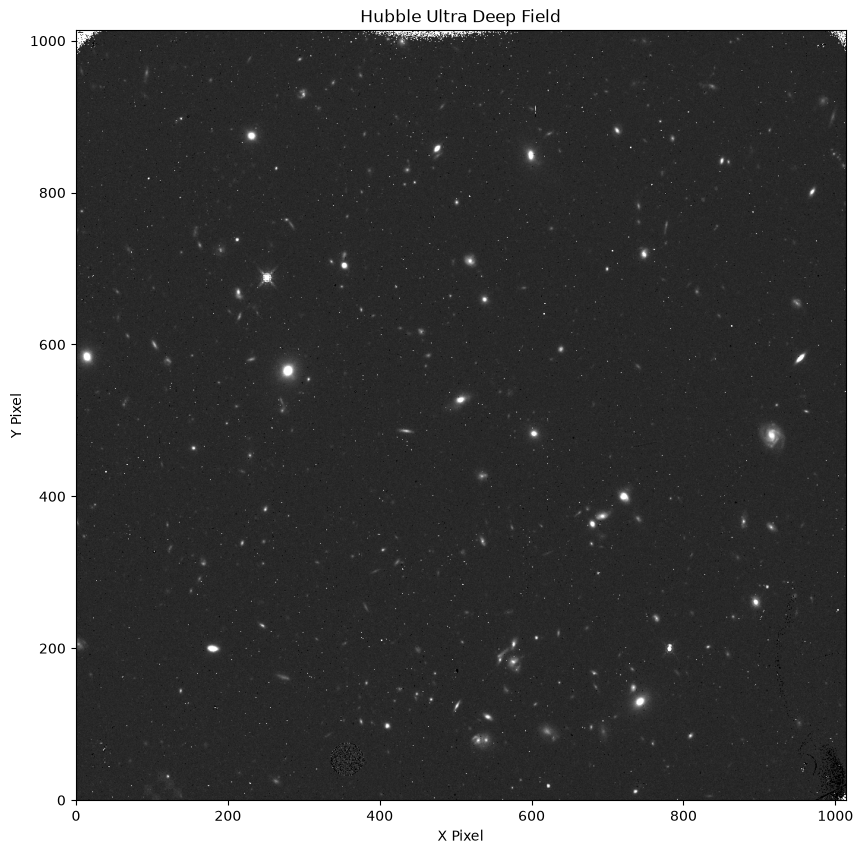

In [3]:
# Cell 4 - Display the Hubble Image ============================

norm = ImageNormalize(
    image,
    interval=PercentileInterval(99.5)
)

plt.imshow(image, cmap="gray", origin="lower", norm=norm)

plt.title("Hubble Ultra Deep Field")

plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

plt.show()

In [4]:
# Cell 5 - Load Clustered Catalog ==============================

catalog = Table.read("../data/catalogs/clustered_galaxies.ecsv")

print("=" * 60)
print("Clustered Catalog")
print("=" * 60)

print(f"Detected objects : {len(catalog)}")
print()

print(catalog.colnames)

Clustered Catalog
Detected objects : 95

['segment_flux', 'area', 'semimajor_axis', 'semiminor_axis', 'eccentricity', 'orientation', 'axis_ratio', 'flux_per_pixel', 'cluster']


In [5]:
# Cell 6 - Cluster Summary =====================================

clusters, counts = np.unique(catalog["cluster"], return_counts=True)

print("=" * 60)
print("Cluster Membership")
print("=" * 60)

for c, n in zip(clusters, counts):
    print(f"Cluster {c}: {n} objects")

Cluster Membership
Cluster 0: 51 objects
Cluster 1: 2 objects
Cluster 2: 42 objects


In [6]:
# Cell 7 - Show only the unusual objects

outliers = catalog[catalog["cluster"] == 1]

outliers

segment_flux,area,semimajor_axis,semiminor_axis,eccentricity,orientation,axis_ratio,flux_per_pixel,cluster
,pix2,pix,pix,,deg,pix,,
float64,float64,float64,float64,float64,float64,float64,float64,int32
4832.935794949532,360.0,8.142243904716647,4.442098615215095,0.8380704852126604,36.308405494019475,1.8329723425832551,13.424821652637588,1
6329.181792199612,549.0,28.61182342485333,2.184390960314212,0.9970814045501614,0.32736941262501135,13.09830700853005,11.528564284516596,1


In [7]:
# Cell 7 - Reload Source Catalog ===============================

source_catalog = Table.read("../data/catalogs/source_catalog.ecsv")

# Add the cluster assignments from Notebook 09
source_catalog["cluster"] = catalog["cluster"]

print("=" * 60)
print("Source Catalog")
print("=" * 60)

print(f"Objects : {len(source_catalog)}")
print()

print(source_catalog.colnames)

Source Catalog
Objects : 95

['label', 'x_centroid', 'y_centroid', 'sky_centroid', 'bbox_xmin', 'bbox_xmax', 'bbox_ymin', 'bbox_ymax', 'area', 'semimajor_axis', 'semiminor_axis', 'orientation', 'eccentricity', 'min_value', 'max_value', 'segment_flux', 'segment_flux_err', 'kron_flux', 'kron_flux_err', 'cluster']


In [8]:
# Cell 8 - Locate AI Outliers =================================

outliers = source_catalog[source_catalog["cluster"] == 1]

columns = [
    "label",
    "x_centroid",
    "y_centroid",
    "segment_flux",
    "area",
    "semimajor_axis",
    "semiminor_axis",
    "eccentricity",
    "cluster"
]

print("=" * 70)
print("Objects Identified as AI Outliers")
print("=" * 70)

outliers[columns]

Objects Identified as AI Outliers


label,x_centroid,y_centroid,segment_flux,area,semimajor_axis,semiminor_axis,eccentricity,cluster
,,,,pix2,pix,pix,,
int32,float64,float64,float64,float64,float64,float64,float64,int32
85,8.851709529799736,1005.5918960462978,4832.935794949532,360.0,8.142243904716647,4.442098615215095,0.8380704852126604,1
89,468.5523186090346,1010.746479456142,6329.181792199612,549.0,28.61182342485333,2.184390960314212,0.9970814045501614,1


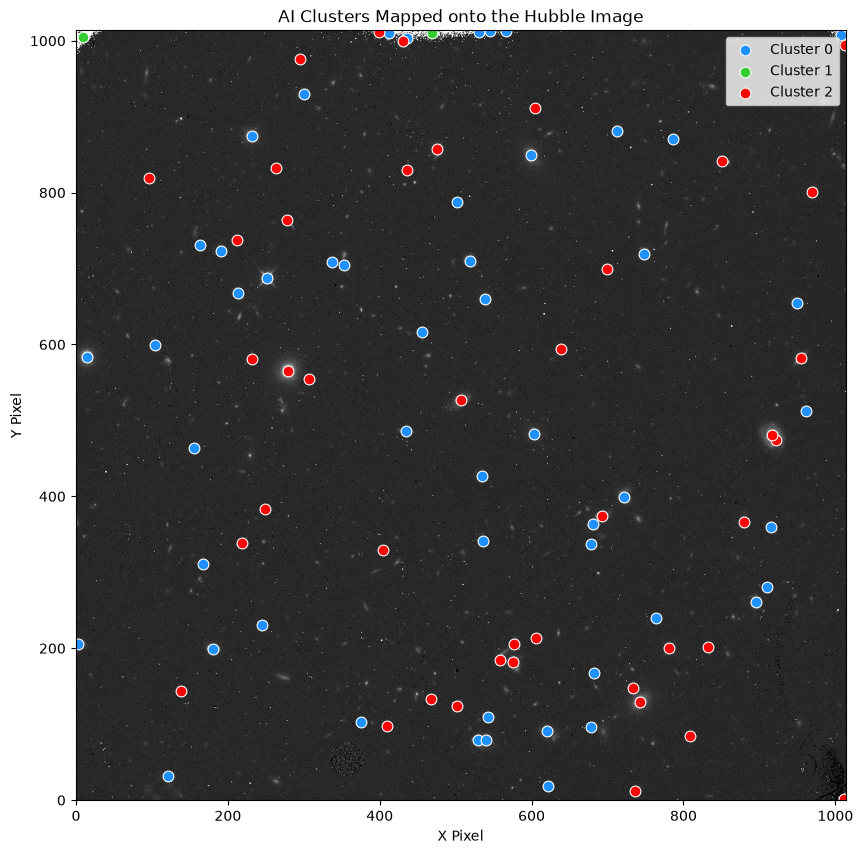

In [9]:
# Cell 9 - Overlay AI Clusters ================================

plt.figure(figsize=(10,10))

norm = ImageNormalize(
    image,
    interval=PercentileInterval(99.5)
)

plt.imshow(
    image,
    cmap="gray",
    origin="lower",
    norm=norm
)

colors = ["dodgerblue", "limegreen", "red"]

for cluster in np.unique(source_catalog["cluster"]):

    subset = source_catalog[source_catalog["cluster"] == cluster]

    plt.scatter(
        subset["x_centroid"],
        subset["y_centroid"],
        s=60,
        edgecolor="white",
        linewidth=0.8,
        color=colors[cluster],
        label=f"Cluster {cluster}"
    )

plt.legend()

plt.title("AI Clusters Mapped onto the Hubble Image")

plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

plt.show()

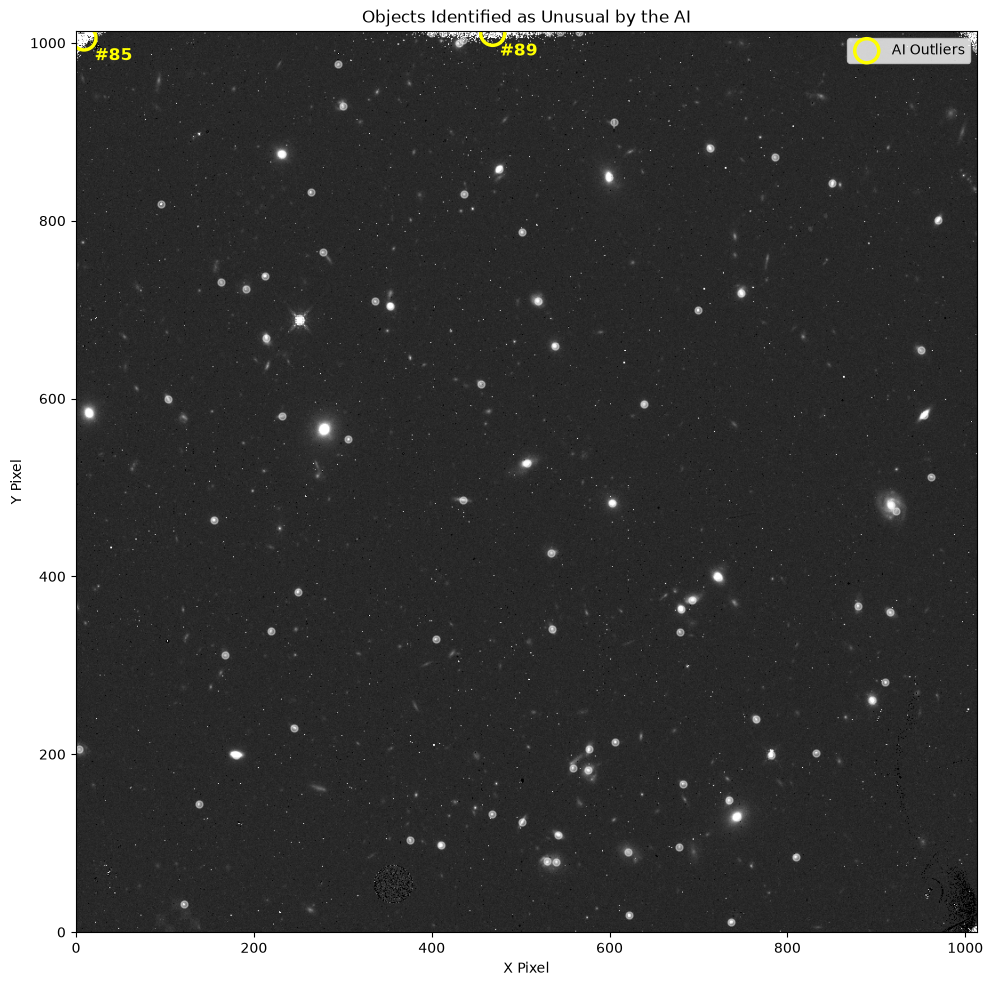

In [10]:
# Cell 10 - Highlight AI Outliers =============================

plt.figure(figsize=(10, 10))

plt.imshow(
    image,
    cmap="gray",
    origin="lower",
    norm=norm
)

# Plot all detected sources
plt.scatter(
    source_catalog["x_centroid"],
    source_catalog["y_centroid"],
    s=25,
    color="white",
    alpha=0.4
)

# Highlight AI outliers
plt.scatter(
    outliers["x_centroid"],
    outliers["y_centroid"],
    s=300,
    facecolors="none",
    edgecolors="yellow",
    linewidths=2.5,
    label="AI Outliers"
)

# Label each outlier without letting the text run off the image
image_height, image_width = image.shape

for row in outliers:

    x = row["x_centroid"]
    y = row["y_centroid"]

    # Default label position
    dx = 8
    dy = 8

    # Keep labels inside image boundaries
    if x < 50:
        dx = 12
    elif x > image_width - 50:
        dx = -45

    if y > image_height - 50:
        dy = -25
    elif y < 50:
        dy = 12

    plt.text(
        x + dx,
        y + dy,
        f"#{row['label']}",
        color="yellow",
        fontsize=12,
        weight="bold"
    )

plt.legend(loc="upper right")

plt.title("Objects Identified as Unusual by the AI")

plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")

plt.tight_layout()
plt.show()

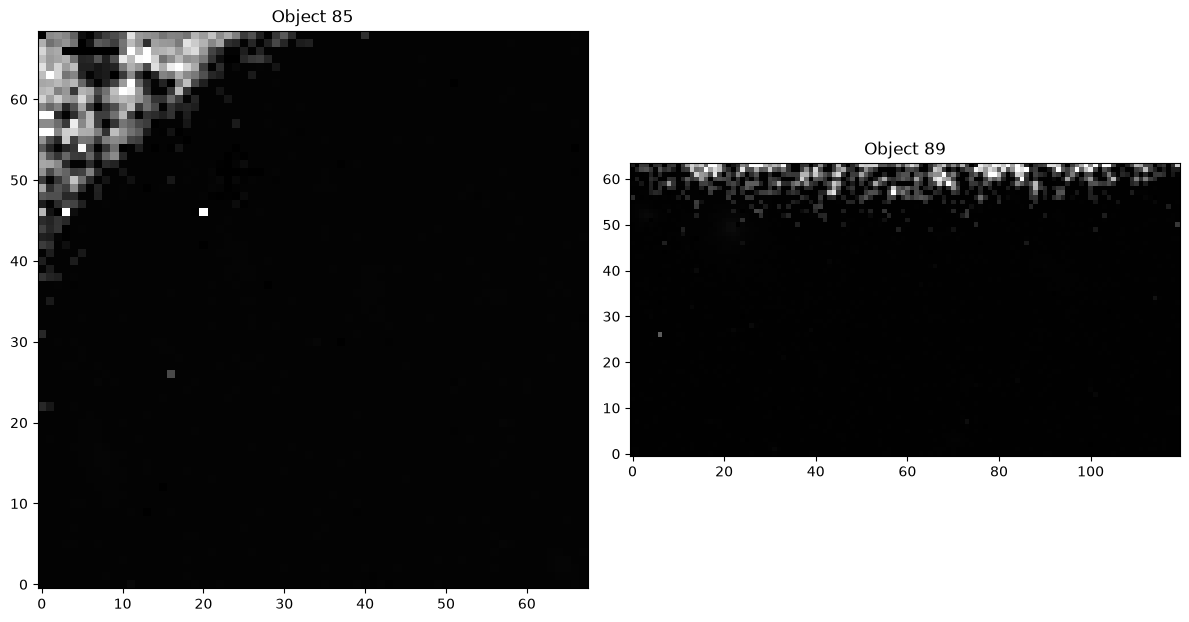

In [11]:
# Cell 11 - Zoom in on AI Outliers =============================

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

box = 60  # pixels

for ax, row in zip(axes, outliers):

    x = int(row["x_centroid"])
    y = int(row["y_centroid"])

    xmin = max(0, x - box)
    xmax = min(image.shape[1], x + box)

    ymin = max(0, y - box)
    ymax = min(image.shape[0], y + box)

    cutout = image[ymin:ymax, xmin:xmax]

    norm = ImageNormalize(
        cutout,
        interval=PercentileInterval(99.5)
    )

    ax.imshow(
        cutout,
        cmap="gray",
        origin="lower",
        norm=norm
    )

    ax.set_title(f"Object {row['label']}")

plt.tight_layout()
plt.show()

In [12]:
Cell 12

margin = 25  # pixels

edge_sources = source_catalog[
    (source_catalog["x_centroid"] < margin) |
    (source_catalog["x_centroid"] > image.shape[1] - margin) |
    (source_catalog["y_centroid"] < margin) |
    (source_catalog["y_centroid"] > image.shape[0] - margin)
]

print(f"Sources near image edge: {len(edge_sources)}")
edge_sources["label", "x_centroid", "y_centroid", "cluster"]

SyntaxError: invalid syntax (3319369163.py, line 1)

In [ ]:
# Cell 13 - Notebook Status ==================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 1_map_ai_clusters_to_hubble_image.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

In [ ]:
# Conclusions

This notebook completed the final stage of the first AI-assisted astronomical
analysis pipeline by mapping machine learning results back onto the original
Hubble image.

## Results

- **95 astronomical sources** were analyzed using unsupervised machine learning.
- K-Means clustering divided the catalog into **three statistical groups**.
- Two objects were identified as strong statistical outliers.

## Investigation

The outlier objects were traced back to their locations in the original Hubble
observation. Visual inspection showed that both sources lie on the **edge of the
detector**, where only part of each object is recorded.

Because these sources are truncated by the image boundary, their measured
properties (brightness, size, and shape) differ substantially from the rest of
the catalog. The machine learning algorithm correctly identified them as
statistical anomalies.

## Scientific Lesson

Machine learning identifies **statistical outliers**, not necessarily unusual
astronomical objects.

Human interpretation remains an essential part of the scientific process.
Returning to the original observations allows researchers to distinguish between
true astrophysical discoveries and artifacts introduced by the observing
process.

## Pipeline Completed

This notebook completes the first end-to-end Cosmic Intelligence Lab workflow:

```
Raw Hubble Image
        ↓
Background Estimation
        ↓
Source Detection
        ↓
Astronomical Catalog
        ↓
Feature Engineering
        ↓
Machine Learning
        ↓
Cluster Analysis
        ↓
Scientific Interpretation
```

This represents the completion of the first fully reproducible AI-assisted
astronomical analysis pipeline developed in the Cosmic Intelligence Lab project.

**Next Steps**

Future notebooks will improve the pipeline by introducing quality-control
filters, removing edge-truncated detections, exploring additional clustering
methods, and ultimately building machine learning models capable of
automatically classifying astronomical objects.

In [ ]:
# Cell 11 - Notebook Status ==================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 10_visualize_clusters_with_pca.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))